In [30]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import sys
sys.path.append("..")
from utils.spatial import is_dominated
from constants import RESULTS_DATA_DIR,RESULTS_DIR

In [31]:
ALGO = "weighted_fpgrowth"

results_df = pd.read_csv(f"../{RESULTS_DIR}/{ALGO}/data/results_CN.csv")
print("Results columns:", results_df.columns)

Results columns: Index(['FOV', 'Antecedents', 'Consequents', 'Lift', 'Confidence', 'Conviction',
       'Support', 'P_Value', 'FDR', 'Rule_Count_Global', 'Biopsy_ID', 'Cohort',
       'Cortico Response', 'Survival at follow-up', 'GI stage', 'Grade GVHD',
       'liver stage', 'skin stage', 'Pathological stage', 'Clinical score',
       'Pathological score', 'Group'],
      dtype='str')


Summary stats for unique rules per FOV:
count     288.000000
mean      727.486111
std       122.270078
min       353.000000
25%       648.500000
50%       725.500000
75%       813.000000
max      1034.000000
Name: Rule, dtype: float64


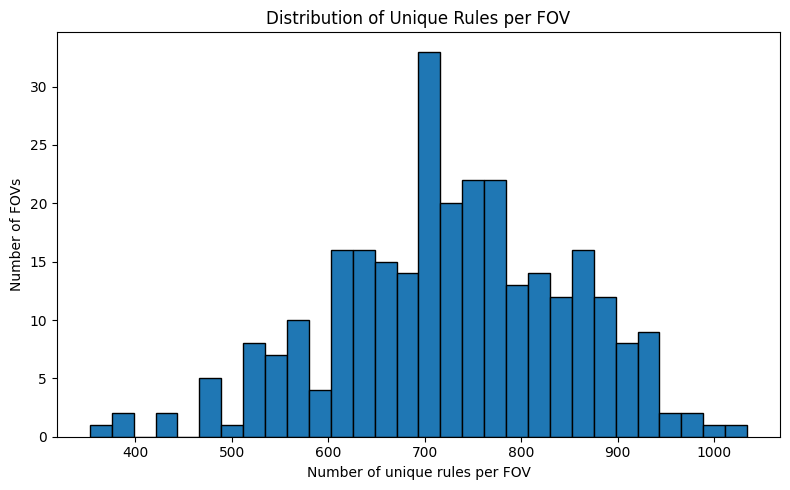

In [32]:
import matplotlib.pyplot as plt

# Define a rule as Antecedents -> Consequents and count unique rules per FOV
tmp = results_df.assign(
    Rule=results_df["Antecedents"].astype(str) + " -> " + results_df["Consequents"].astype(str)
)
unique_rules_per_fov = tmp.groupby("FOV")["Rule"].nunique()

print("Summary stats for unique rules per FOV:")
print(unique_rules_per_fov.describe())

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(unique_rules_per_fov, bins=30, edgecolor="black")
plt.xlabel("Number of unique rules per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Unique Rules per FOV")
plt.tight_layout()
plt.show()

Lift summary per FOV:
                  count       mean        std       min        25%        50%  \
FOV                                                                             
Control_01_FOV_1  780.0  25.459104  13.914842  0.253085  28.230475  31.809699   
Control_01_FOV_2  840.0  21.247708  14.239642  0.206974   0.433756  28.817831   
Control_01_FOV_3  872.0  22.983186  15.471474  0.281751   0.401020  30.425722   
Control_01_FOV_4  860.0  18.159289  16.767214  0.223525   0.468925  26.920089   
Control_02_FOV_1  714.0  20.491118  16.127609  0.198306   0.355984  20.176483   

                        75%        max  
FOV                                     
Control_01_FOV_1  34.088717  45.993316  
Control_01_FOV_2  31.653222  38.103954  
Control_01_FOV_3  33.066440  46.670982  
Control_01_FOV_4  29.690316  56.145821  
Control_02_FOV_1  27.037505  63.492429  


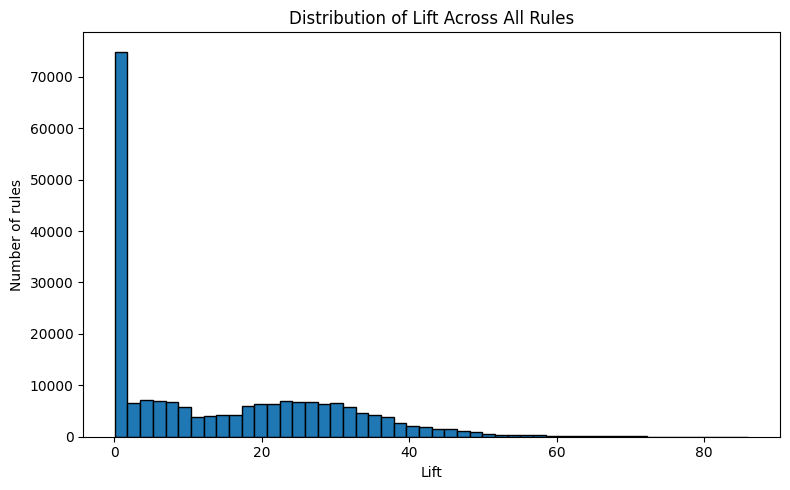

<Figure size 800x500 with 0 Axes>

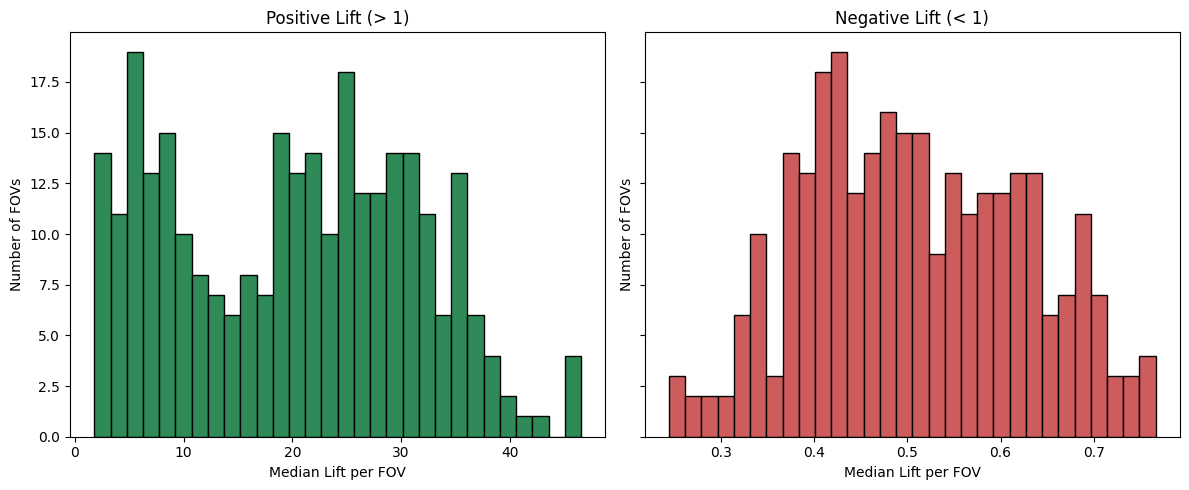

In [33]:
# Distribution of lift values across rules, summarized per FOV
lift_stats_per_fov = results_df.groupby("FOV")["Lift"].describe()

print("Lift summary per FOV:")
print(lift_stats_per_fov[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head())

# Histogram of all lift values
plt.figure(figsize=(8, 5))
plt.hist(results_df["Lift"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Lift")
plt.ylabel("Number of rules")
plt.title("Distribution of Lift Across All Rules")
plt.tight_layout()
plt.show()

# Histogram of per-FOV median lift
# Compute separate per-FOV medians for positive and negative lift, then combine
median_pos_lift_per_fov = results_df[results_df["Lift"] > 1].groupby("FOV")["Lift"].median()
median_neg_lift_per_fov = results_df[results_df["Lift"] < 1].groupby("FOV")["Lift"].median()

# Keep a single series for downstream histogram/splitting code
median_lift_per_fov = pd.concat([median_pos_lift_per_fov, median_neg_lift_per_fov])

plt.figure(figsize=(8, 5))
plt.hist(median_lift_per_fov.dropna(), bins=30, edgecolor="black")
plt.xlabel("Median Lift per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Median Lift per FOV")
plt.tight_layout()
plt.clf()

positive_lift = median_lift_per_fov[median_lift_per_fov > 1].dropna()
negative_lift = median_lift_per_fov[median_lift_per_fov < 1].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(positive_lift, bins=30, edgecolor="black", color="seagreen")
axes[0].set_title("Positive Lift (> 1)")
axes[0].set_xlabel("Median Lift per FOV")
axes[0].set_ylabel("Number of FOVs")

axes[1].hist(negative_lift, bins=30, edgecolor="black", color="indianred")
axes[1].set_title("Negative Lift (< 1)")
axes[1].set_xlabel("Median Lift per FOV")
axes[1].set_ylabel("Number of FOVs")

plt.tight_layout()
plt.show()

In [34]:
# Keep rules with strong positive or negative association
lift_keep_mask = (results_df["Lift"] > 1.3) | (results_df["Lift"] < 0.7)

n_total_rules = len(results_df)
n_kept_rules = lift_keep_mask.sum()
n_removed_rules = n_total_rules - n_kept_rules
pct_kept = 100 * n_kept_rules / n_total_rules

print(f"Total rules:   {n_total_rules:,}")
print(f"Kept rules:    {n_kept_rules:,} ({pct_kept:.2f}%)")
print(f"Removed rules: {n_removed_rules:,}")

# Optional: split kept rules by side of threshold
n_gt_13 = (results_df["Lift"] > 1.3).sum()
n_lt_07 = (results_df["Lift"] < 0.7).sum()
print(f"\nKept with Lift > 1.3: {n_gt_13:,}")
print(f"Kept with Lift < 0.7: {n_lt_07:,}")

Total rules:   209,516
Kept rules:    201,803 (96.32%)
Removed rules: 7,713

Kept with Lift > 1.3: 135,441
Kept with Lift < 0.7: 66,362


### Support Value Distribution

Support summary per FOV:
                  count      mean       std       min       25%       50%  \
FOV                                                                         
Control_01_FOV_1  780.0  0.013697  0.003010  0.010003  0.011447  0.013096   
Control_01_FOV_2  840.0  0.014446  0.004833  0.010016  0.011026  0.012628   
Control_01_FOV_3  872.0  0.012618  0.002416  0.010019  0.010889  0.011733   
Control_01_FOV_4  860.0  0.015060  0.006473  0.010009  0.010989  0.012978   
Control_02_FOV_1  714.0  0.013871  0.004221  0.010025  0.010784  0.012481   

                       75%       max  
FOV                                   
Control_01_FOV_1  0.015054  0.029406  
Control_01_FOV_2  0.015753  0.041005  
Control_01_FOV_3  0.013458  0.023925  
Control_01_FOV_4  0.016509  0.073320  
Control_02_FOV_1  0.015363  0.034524  


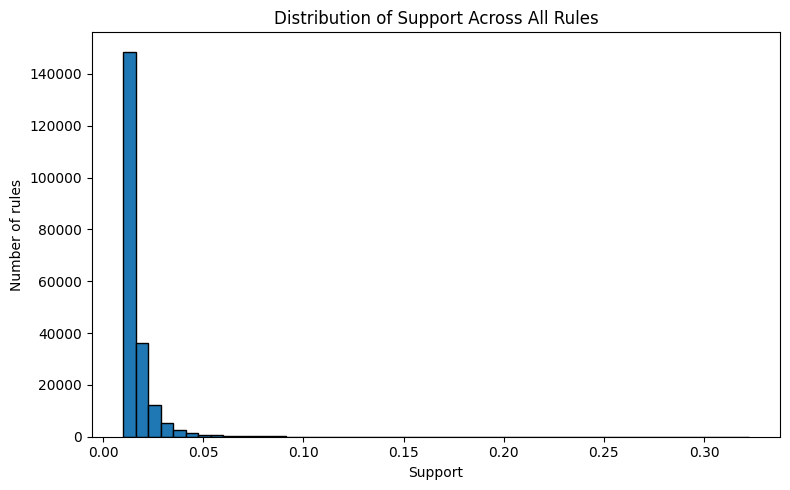

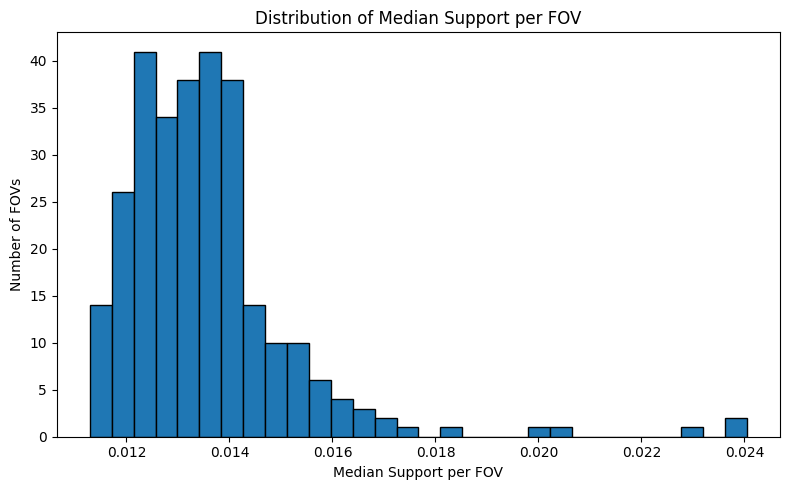

In [35]:
# Distribution of support values across rules, summarized per FOV
support_stats_per_fov = results_df.groupby("FOV")["Support"].describe()

print("Support summary per FOV:")
print(support_stats_per_fov[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head())

# Histogram of all support values
plt.figure(figsize=(8, 5))
plt.hist(results_df["Support"].dropna(), bins=50, edgecolor="black")
plt.xlabel("Support")
plt.ylabel("Number of rules")
plt.title("Distribution of Support Across All Rules")
plt.tight_layout()
plt.show()

# Histogram of median support per FOV
median_support_per_fov = results_df.groupby("FOV")["Support"].median()

plt.figure(figsize=(8, 5))
plt.hist(median_support_per_fov.dropna(), bins=30, edgecolor="black")
plt.xlabel("Median Support per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Median Support per FOV")
plt.tight_layout()
plt.show()

In [36]:
print("Total rules:", len(results_df))
print("Rules with Support > 0.03:", (results_df["Support"] > 0.03).sum())
print("Rules with Support > 0.04:", (results_df["Support"] > 0.04).sum())
print("Rules with Support > 0.05:", (results_df["Support"] > 0.05).sum())

Total rules: 209516
Rules with Support > 0.03: 10903
Rules with Support > 0.04: 4717
Rules with Support > 0.05: 2569


c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Owner\Documents\script-rule-mining\venv\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Owner\Documents\scrip

Conviction summary per FOV:
                  count      mean        std       min       25%       50%  \
FOV                                                                          
Control_01_FOV_1  780.0       inf        NaN  0.448173  1.550555  2.232812   
Control_01_FOV_2  840.0       inf        NaN  0.250201  0.920995  1.836491   
Control_01_FOV_3  872.0  3.567498  14.354026  0.557638  0.911802  2.073114   
Control_01_FOV_4  860.0       inf        NaN  0.457527  0.945670  1.565466   
Control_02_FOV_1  714.0       inf        NaN  0.420759  0.911146  1.867883   

                       75%         max  
FOV                                     
Control_01_FOV_1  3.340379         inf  
Control_01_FOV_2  3.350349         inf  
Control_01_FOV_3  3.394843  404.362459  
Control_01_FOV_4  2.420135         inf  
Control_02_FOV_1  2.852353         inf  


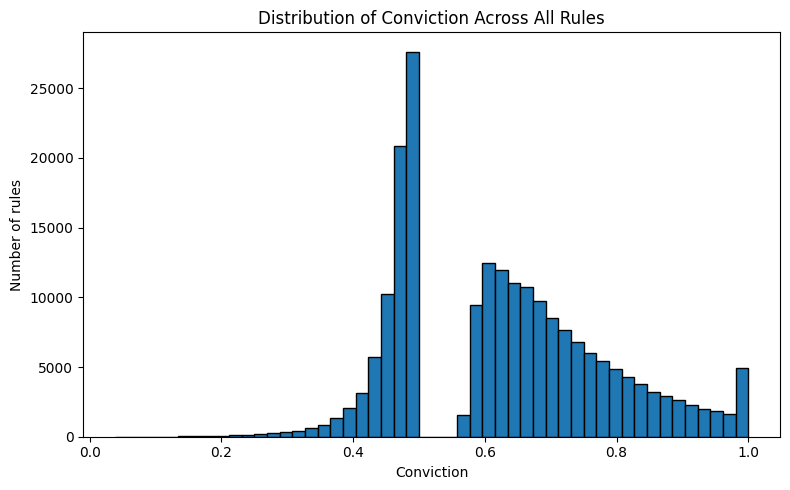

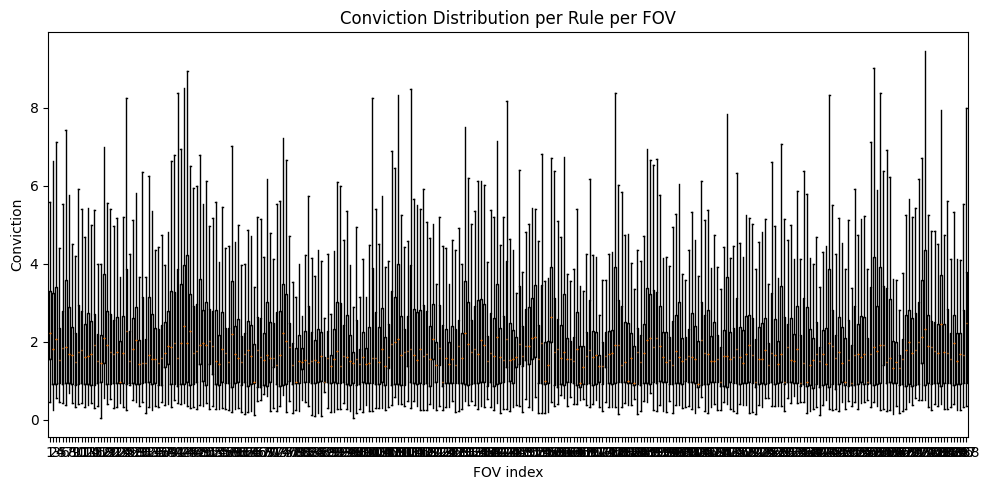

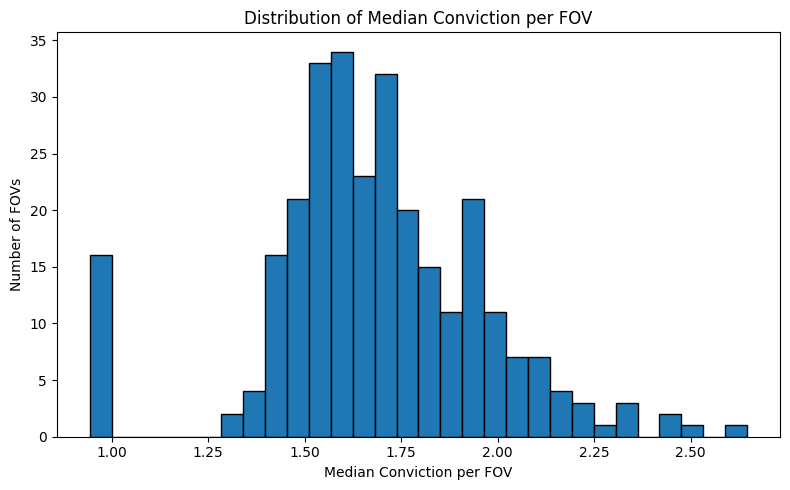

In [37]:
# Distribution of conviction values across rules, summarized per FOV
conviction_stats_per_fov = results_df.groupby("FOV")["Conviction"].describe()

print("Conviction summary per FOV:")
print(conviction_stats_per_fov[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].head())

# Histogram of all conviction values
plt.figure(figsize=(8, 5))
conv_raw = results_df["Conviction"].astype(float)

# Map conviction to [0, 1): x -> x / (1 + x), and force +inf to 1
conviction_values = pd.Series(
    np.where(np.isposinf(conv_raw), 1.0, conv_raw / (1.0 + conv_raw)),
    index=conv_raw.index
).replace([np.inf, -np.inf], np.nan).dropna().clip(0, 1)

plt.hist(conviction_values, bins=50, edgecolor="black")
plt.xlabel("Conviction")
plt.ylabel("Number of rules")
plt.title("Distribution of Conviction Across All Rules")
plt.tight_layout()

# Per-rule conviction distribution within each FOV
conviction_by_fov = [
    g.replace([np.inf, -np.inf], np.nan).dropna().values
    for _, g in results_df.groupby("FOV")["Conviction"]
]

plt.figure(figsize=(10, 5))
plt.boxplot(conviction_by_fov, showfliers=False)
plt.xlabel("FOV index")
plt.ylabel("Conviction")
plt.title("Conviction Distribution per Rule per FOV")
plt.tight_layout()
plt.show()

# Histogram of median conviction per FOV
median_conviction_per_fov = results_df.groupby("FOV")["Conviction"].median()

plt.figure(figsize=(8, 5))
plt.hist(median_conviction_per_fov.dropna(), bins=30, edgecolor="black")
plt.xlabel("Median Conviction per FOV")
plt.ylabel("Number of FOVs")
plt.title("Distribution of Median Conviction per FOV")
plt.tight_layout()
plt.show()

Summary stats for number of items per rule:
count    209516.000000
mean          4.397717
std           0.788787
min           2.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
dtype: float64


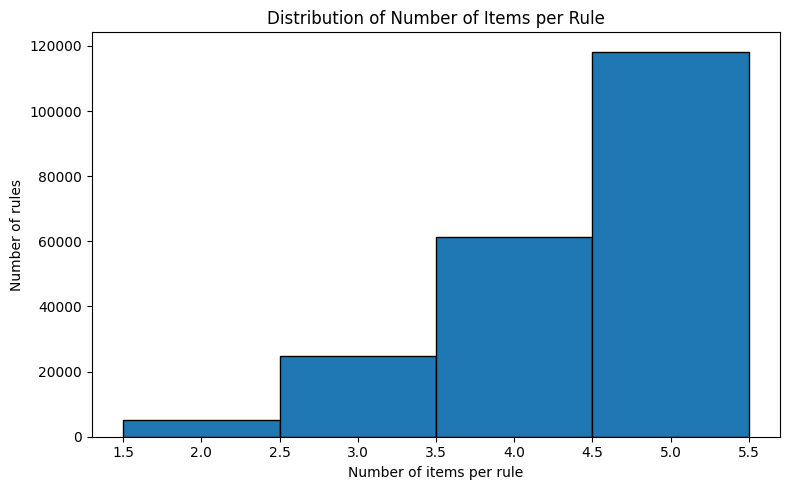

In [38]:
# Calculate the number of items in each rule (antecedents + consequents)
n_items_per_rule = results_df["Antecedents"].apply(lambda x: len(eval(x))) + results_df["Consequents"].apply(lambda x: len(eval(x)))

print("Summary stats for number of items per rule:")
print(n_items_per_rule.describe())

plt.figure(figsize=(8, 5))
plt.hist(n_items_per_rule, bins=range(n_items_per_rule.min(), n_items_per_rule.max() + 2), edgecolor="black", align="left")
plt.xlabel("Number of items per rule")
plt.ylabel("Number of rules")
plt.title("Distribution of Number of Items per Rule")
plt.tight_layout()
plt.show()

In [45]:
# Find two rules where one is an extension of the other: a->c and a,b->c
fov_df = results_df[results_df["FOV"] == "Control_10_FOV_2"]
# Convert string representation of lists to actual lists for Antecedents and Consequents
fov_df['Antecedents_list'] = fov_df['Antecedents'].apply(eval)
fov_df['Consequents_list'] = fov_df['Consequents'].apply(eval)

# We'll search for pairs with the same Consequents, and one Antecedent list is a subset of the other
found = False
for idx1, row1 in fov_df.iterrows():
    for idx2, row2 in fov_df.iterrows():
        if idx1 == idx2:
            continue
        if row1['FOV'] != row2['FOV']: continue
        # Same Consequents
        if row1['Consequents_list'] == row2['Consequents_list']:
            set1 = set(row1['Antecedents_list'])
            set2 = set(row2['Antecedents_list'])
            # One is a strict subset of the other
            if set1 < set2:
                print("Rule 1 (smaller antecedent):")
                print(f"Antecedents: {row1['Antecedents_list']} -> Consequents: {row1['Consequents_list']}")
                print(f"Lift: {row1['Lift']}, Confidence: {row1['Confidence']}, Conviction: {row1['Conviction']}, Support: {row1['Support']}")
                print("\nRule 2 (extension):")
                print(f"Antecedents: {row2['Antecedents_list']} -> Consequents: {row2['Consequents_list']}")
                print(f"Lift: {row2['Lift']}, Confidence: {row2['Confidence']}, Conviction: {row2['Conviction']}, Support: {row2['Support']}")
                # Calculate leverage for both rules
                lev1 = row1['Support'] - (
                    results_df[(results_df['FOV'] == row1['FOV']) &
                               (results_df['Antecedents'] == str(row1['Antecedents_list']))]['Support'].iloc[0] *
                    results_df[(results_df['FOV'] == row1['FOV']) &
                               (results_df['Consequents'] == str(row1['Consequents_list']))]['Support'].iloc[0]
                )
                lev2 = row2['Support'] - (
                    results_df[(results_df['FOV'] == row2['FOV']) &
                               (results_df['Antecedents'] == str(row2['Antecedents_list']))]['Support'].iloc[0] *
                    results_df[(results_df['FOV'] == row2['FOV']) &
                               (results_df['Consequents'] == str(row2['Consequents_list']))]['Support'].iloc[0]
                )
                print(f"Leverage Rule 1: {lev1:.6f}")
                print(f"Leverage Rule 2: {lev2:.6f}")
                found = True
                break
    if found:
        break
if not found:
    print("No such rule pair found.")

Rule 1 (smaller antecedent):
Antecedents: ['CD4T_CD69+_CENTER', 'SMV_NEIGHBOR'] -> Consequents: ['CD4T_CENTER', 'CD4T_NEIGHBOR']
Lift: 29.42674323670108, Confidence: 0.8357885374222739, Conviction: 5.916746851528501, Support: 0.0181744962291951

Rule 2 (extension):
Antecedents: ['CD4T_CD69+_CENTER', 'Fibroblast_NEIGHBOR', 'SMV_NEIGHBOR'] -> Consequents: ['CD4T_CENTER', 'CD4T_NEIGHBOR']
Lift: 32.51502629264408, Confidence: 0.9235030207312314, Conviction: 12.701124455881942, Support: 0.0115375193625603
Leverage Rule 1: 0.017931
Leverage Rule 2: 0.011284
